In [5]:
import pandas as pd
import numpy as np

PATH = "../data/processed/netload/f10_netload_nasa_clean.csv"
df = pd.read_csv(PATH, parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

# keep only what hybrid needs
cols = ["Timestamp", "NetLoad_MW", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]
df = df[cols].copy()

df.head(), df.tail(), df.shape

(            Timestamp  NetLoad_MW  ALLSKY_SFC_SW_DWN    T2M  WS10M
 0 2025-03-31 15:45:00      -1.356             425.48  31.07   3.42
 1 2025-03-31 16:00:00      -0.353             194.80  30.73   3.49
 2 2025-03-31 16:15:00       0.509             194.80  30.73   3.49
 3 2025-03-31 16:30:00       1.902             194.80  30.73   3.49
 4 2025-03-31 16:45:00       2.148             194.80  30.73   3.49,
                 Timestamp  NetLoad_MW  ALLSKY_SFC_SW_DWN    T2M  WS10M
 14779 2025-09-01 14:30:00      -0.331             390.60  30.52   4.32
 14780 2025-09-01 14:45:00       0.169             390.60  30.52   4.32
 14781 2025-09-01 15:00:00       0.888             246.32  30.28   4.47
 14782 2025-09-01 15:15:00       1.433             246.32  30.28   4.47
 14783 2025-09-01 15:30:00       1.677             246.32  30.28   4.47,
 (14784, 5))

### Apply the exact same split boundaries

In [6]:
train_end = pd.Timestamp("2025-07-15 00:00:00")
test_start = pd.Timestamp("2025-08-01 00:00:00")

df_train = df[df["Timestamp"] < train_end].copy()
df_val   = df[(df["Timestamp"] >= train_end) & (df["Timestamp"] < test_start)].copy()
df_test  = df[df["Timestamp"] >= test_start].copy()

print("Train:", df_train.shape, df_train["Timestamp"].min(), "→", df_train["Timestamp"].max())
print("Val:  ", df_val.shape,   df_val["Timestamp"].min(),   "→", df_val["Timestamp"].max())
print("Test: ", df_test.shape,  df_test["Timestamp"].min(),  "→", df_test["Timestamp"].max())

Train: (10113, 5) 2025-03-31 15:45:00 → 2025-07-14 23:45:00
Val:   (1632, 5) 2025-07-15 00:00:00 → 2025-07-31 23:45:00
Test:  (3039, 5) 2025-08-01 00:00:00 → 2025-09-01 15:30:00


### Build issue times (one forecast per day at 23:45) + ensure next-day exists

In [7]:
ISSUE_TIME = "23:45"
H = 96  # next day 96 points

def daily_issue_times(df_block, issue_time="23:45"):
    days = pd.to_datetime(df_block["Timestamp"].dt.date.unique())
    issue_ts = [pd.Timestamp(f"{d.date()} {issue_time}") for d in days]
    existing = set(df_block["Timestamp"])
    return [t for t in issue_ts if t in existing]

ts_set = set(df["Timestamp"])

def has_next_day(t, horizon=96):
    start = t + pd.Timedelta(minutes=15)
    times = [start + pd.Timedelta(minutes=15*i) for i in range(horizon)]
    return all(x in ts_set for x in times)

train_issue = [t for t in daily_issue_times(df_train, ISSUE_TIME) if has_next_day(t, H)]
val_issue   = [t for t in daily_issue_times(df_val, ISSUE_TIME)   if has_next_day(t, H)]
test_issue  = [t for t in daily_issue_times(df_test, ISSUE_TIME)  if has_next_day(t, H)]

print("Train issue days:", len(train_issue), "|", train_issue[0], "→", train_issue[-1])
print("Val issue days:  ", len(val_issue),   "|", val_issue[0],   "→", val_issue[-1])
print("Test issue days: ", len(test_issue),  "|", test_issue[0],  "→", test_issue[-1])

Train issue days: 106 | 2025-03-31 23:45:00 → 2025-07-14 23:45:00
Val issue days:   17 | 2025-07-15 23:45:00 → 2025-07-31 23:45:00
Test issue days:  30 | 2025-08-01 23:45:00 → 2025-08-30 23:45:00


In [8]:
t = test_issue[0]
start = t + pd.Timedelta(minutes=15)
end = start + pd.Timedelta(minutes=15*(H-1))
print("Issue:", t)
print("Target range:", start, "→", end)

Issue: 2025-08-01 23:45:00
Target range: 2025-08-02 00:00:00 → 2025-08-02 23:45:00


### ICEEMDAN energy check (run once)

In [5]:
!pip install EMD-signal

Defaulting to user installation because normal site-packages is not writeable
  Using cached emd_signal-1.9.0-py3-none-any.whl.metadata (9.7 kB)
  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
Using cached emd_signal-1.9.0-py3-none-any.whl (76 kB)
Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl (12.3 MB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 8.5 MB/s eta 0:00:05
   -- ------------------------------------- 1.8/36.5 MB 5.9 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/36.5 MB 5.2 MB/s eta 0:00:07
   ---- ----------------------------------- 3.7/36.5 MB 5.0 MB/s eta 0:00:07
   ----- ---------------------------------- 4.7/36.5 MB 5.1 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/36.5 MB 5.1 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/36.5 MB 5.1 MB/s eta


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [9]:
from PyEMD import CEEMDAN
print(" CEEMDAN import OK")

 CEEMDAN import OK


### CEEMDAN energy check on ONE 7-day TRAIN window 

In [10]:
from PyEMD import CEEMDAN
import numpy as np
import pandas as pd

np.random.seed(42)

t_check = pd.to_datetime(train_issue[10])

W_DAYS = 7
N = W_DAYS * 96

start = t_check - pd.Timedelta(minutes=15*(N-1))
idx = pd.date_range(start, t_check, freq="15min")

win = df_train.set_index("Timestamp").reindex(idx)
if win["NetLoad_MW"].isna().any():
    raise ValueError("Missing points in window. Pick a later t_check.")

x = win["NetLoad_MW"].to_numpy(dtype=float)

ce = CEEMDAN()
ce.random_seed = 42
ce.max_imf = 6         

imfs = ce.ceemdan(x)

energies = np.sum(imfs**2, axis=1)
pct = energies / (energies.sum() + 1e-12) * 100

for i, p in enumerate(pct, start=1):
    print(f"IMF{i}: {p:.2f}%")
print("IMF1-IMF3 total %:", float(pct[:3].sum()))

IMF1: 0.35%
IMF2: 5.92%
IMF3: 62.82%
IMF4: 15.57%
IMF5: 1.26%
IMF6: 14.07%
IMF1-IMF3 total %: 69.09278247549267


### Denoise function (DROP_IMFS = 1)

In [11]:
DROP_IMFS = 1  # drop only IMF1

# create once (reuse)
ce = CEEMDAN()
ce.random_seed = 42

# speed knobs (safe for denoising)
if hasattr(ce, "max_imf"):
    ce.max_imf = 6
if hasattr(ce, "trials"):
    ce.trials = 30

def denoise_ceemdan(x, drop_imfs=1):
    x = np.asarray(x, dtype=float)

    imfs = ce.ceemdan(x)  # (K, N)
    residual = x - imfs.sum(axis=0)

    if imfs.shape[0] > drop_imfs:
        kept = imfs[drop_imfs:, :].sum(axis=0)
    else:
        kept = np.zeros_like(x)

    return kept + residual

# sanity check
den = denoise_ceemdan(x, drop_imfs=DROP_IMFS)
print("denoised len:", len(den), "| orig len:", len(x))

denoised len: 672 | orig len: 672


### Build 1 sample at one issue time

In [12]:
import os
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN

# ----------------------------
# Settings
# ----------------------------
DROP_IMFS = 1          # drop only IMF1
L = 192                # input length (2 days)
H = 96                 # horizon (next day, 96 x 15min)
D = 2 * 96             #  denoise window = 2 days (192 points) for speed

CACHE_DIR = "denoise_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# ----------------------------
# Fast-ish CEEMDAN setup (reuse one object)
# ----------------------------
np.random.seed(42)
ce = CEEMDAN()
ce.random_seed = 42

# speed knobs (only for denoising)
if hasattr(ce, "max_imf"):
    ce.max_imf = 6     # try 6–8
if hasattr(ce, "trials"):
    ce.trials = 10     #  faster (try 10–30)

def denoise_ceemdan(x, drop_imfs=DROP_IMFS):
    """
    CEEMDAN denoise on a past-only window x.
    Reconstruct = sum(IMFs after dropped ones) + residual
    """
    x = np.asarray(x, dtype=float)
    imfs = ce.ceemdan(x)  # (K, N)

    residual = x - imfs.sum(axis=0)
    if imfs.shape[0] > drop_imfs:
        kept = imfs[drop_imfs:, :].sum(axis=0)
    else:
        kept = np.zeros_like(x)

    return kept + residual

def denoise_cached(split_name, issue_time, netload_series):
    """
     Disk cache per issue day + per split (train/val/test).
    """
    day = pd.to_datetime(issue_time).strftime("%Y-%m-%d")
    fpath = os.path.join(CACHE_DIR, f"{split_name}_den_{day}_D{D}_drop{DROP_IMFS}.npy")

    if os.path.exists(fpath):
        return np.load(fpath)

    den = denoise_ceemdan(netload_series, drop_imfs=DROP_IMFS)
    np.save(fpath, den)
    return den

# ----------------------------
# Build 1 sample at one issue time
# ----------------------------
t = pd.to_datetime(train_issue[10])  # issue time (23:45)

df_train_i = (df_train.copy()
              .assign(Timestamp=lambda d: pd.to_datetime(d["Timestamp"]))
              .sort_values("Timestamp")
              .set_index("Timestamp"))

# past D points for denoise (past-only)
hist_start = t - pd.Timedelta(minutes=15*(D-1))
hist_idx = pd.date_range(hist_start, t, freq="15min")

# next H points target
y_idx = pd.date_range(t + pd.Timedelta(minutes=15),
                      t + pd.Timedelta(minutes=15*H),
                      freq="15min")[:H]

assert hist_idx.isin(df_train_i.index).all(), "Missing history points"
assert y_idx.isin(df_train_i.index).all(), "Missing target points"

hist = df_train_i.loc[hist_idx, ["NetLoad_MW", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]]
future = df_train_i.loc[y_idx, ["NetLoad_MW"]]

#  denoise net load (past only) + cache (train split)
x_den = denoise_cached("train", t, hist["NetLoad_MW"].to_numpy())

# X: last L points (denoised netload + exo)
X = np.concatenate([
    x_den[-L:].reshape(L, 1),
    hist[["ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]].to_numpy()[-L:, :]
], axis=1)

# y: next day netload (H points)
y = future["NetLoad_MW"].to_numpy().reshape(-1)

print("Issue:", t)
print("X:", X.shape, "y:", y.shape)
print("X range:", hist_idx[-L], "→", hist_idx[-1])
print("y range:", y_idx[0], "→", y_idx[-1])
print("Cache file:", os.path.join(CACHE_DIR, f"train_den_{pd.to_datetime(t).strftime('%Y-%m-%d')}_D{D}_drop{DROP_IMFS}.npy"))

Issue: 2025-04-10 23:45:00
X: (192, 4) y: (96,)
X range: 2025-04-09 00:00:00 → 2025-04-10 23:45:00
y range: 2025-04-11 00:00:00 → 2025-04-11 23:45:00
Cache file: denoise_cache\train_den_2025-04-10_D192_drop1.npy


### 1) Build all samples for train/val/test (with caching)

In [13]:
import numpy as np
import pandas as pd

def build_samples(df_block, issue_times, split_name, L=192, H=96, D=192):
    df_i = (df_block.copy()
            .assign(Timestamp=lambda d: pd.to_datetime(d["Timestamp"]))
            .sort_values("Timestamp")
            .set_index("Timestamp"))

    X_list, y_list = [], []

    for k, t in enumerate(map(pd.to_datetime, issue_times), start=1):

        hist_start = t - pd.Timedelta(minutes=15*(D-1))
        hist_idx = pd.date_range(hist_start, t, freq="15min")

        y_idx = pd.date_range(t + pd.Timedelta(minutes=15),
                              t + pd.Timedelta(minutes=15*H),
                              freq="15min")[:H]

        if (not hist_idx.isin(df_i.index).all()) or (not y_idx.isin(df_i.index).all()):
            continue

        hist = df_i.loc[hist_idx, ["NetLoad_MW","ALLSKY_SFC_SW_DWN","T2M","WS10M"]]
        future = df_i.loc[y_idx, ["NetLoad_MW"]]

        x_den = denoise_cached(split_name, t, hist["NetLoad_MW"].to_numpy())

        X = np.concatenate([
            x_den[-L:].reshape(L, 1),
            hist[["ALLSKY_SFC_SW_DWN","T2M","WS10M"]].to_numpy()[-L:, :]
        ], axis=1)

        y = future["NetLoad_MW"].to_numpy()

        X_list.append(X)
        y_list.append(y)

        if k % 10 == 0:
            print(f"{split_name}: {k}/{len(issue_times)} done")

    return np.stack(X_list), np.stack(y_list)

X_train, y_train = build_samples(df_train, train_issue, "train", L=L, H=H, D=D)
X_val,   y_val   = build_samples(df_val,   val_issue,   "val",   L=L, H=H, D=D)
X_test,  y_test  = build_samples(df_test,  test_issue,  "test",  L=L, H=H, D=D)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

train: 10/106 done
train: 20/106 done
train: 30/106 done
train: 40/106 done
train: 50/106 done
train: 60/106 done
train: 70/106 done
train: 80/106 done
train: 90/106 done
train: 100/106 done
val: 10/17 done
test: 10/30 done
test: 20/30 done
test: 30/30 done
Train: (103, 192, 4) (103, 96)
Val:   (15, 192, 4) (15, 96)
Test:  (29, 192, 4) (29, 96)


### 2) Scale X and y (fit on TRAIN only)

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---- safety checks ----
assert not np.isnan(X_train).any(), "NaNs in X_train"
assert not np.isnan(y_train).any(), "NaNs in y_train"
assert np.isfinite(X_train).all(), "Inf in X_train"
assert np.isfinite(y_train).all(), "Inf in y_train"

# ---- scale X (fit on TRAIN only) ----
x_scaler = StandardScaler()
x_scaler.fit(X_train.reshape(-1, 4))

X_train_s = x_scaler.transform(X_train.reshape(-1, 4)).reshape(X_train.shape)
X_val_s   = x_scaler.transform(X_val.reshape(-1, 4)).reshape(X_val.shape)
X_test_s  = x_scaler.transform(X_test.reshape(-1, 4)).reshape(X_test.shape)

# ---- scale y (fit on TRAIN only) ----
y_scaler = StandardScaler()
y_scaler.fit(y_train.reshape(-1, 1))

y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_val_s   = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_s  = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

print("Scaled:", X_train_s.shape, y_train_s.shape)

Scaled: (103, 192, 4) (103, 96)


### 3) create PyTorch DataLoaders

In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# tensors
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train_s, dtype=torch.float32)
Xva = torch.tensor(X_val_s,   dtype=torch.float32)
yva = torch.tensor(y_val_s,   dtype=torch.float32)

train_ds = TensorDataset(Xtr, ytr)
val_ds   = TensorDataset(Xva, yva)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))
print("One batch shapes:", next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)

Train batches: 7 Val batches: 1
One batch shapes: torch.Size([16, 192, 4]) torch.Size([16, 96])


In [17]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("cuda device name:", torch.cuda.get_device_name(0))
    print("cuda capability:", torch.cuda.get_device_capability(0))
    print("current device:", torch.cuda.current_device())
else:
    print("No CUDA detected by PyTorch (will use CPU).")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch version: 2.9.1+cpu
cuda available: False
No CUDA detected by PyTorch (will use CPU).
Using device: cpu


Define a CPU-friendly Transformer that maps (192,4) → (96,)

In [18]:
import numpy as np
import torch
import torch.nn as nn

# ---- Positional Encoding (sinusoidal) ----
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, d_model)
        L = x.size(1)
        x = x + self.pe[:, :L, :]
        return self.dropout(x)

# ---- Transformer Encoder for direct multi-step forecasting ----
class ForecastTransformer(nn.Module):
    """
    Direct multi-step: encodes past (L=192) and outputs horizon (H=96).
    Input : (B, 192, 4)
    Output: (B, 96)
    """
    def __init__(
        self,
        n_features=4,
        seq_len=192,
        horizon=96,
        d_model=32,          # CPU-friendly
        nhead=4,
        num_layers=2,
        dim_ff=64,
        dropout=0.1,
    ):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=seq_len + 5, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Pool sequence -> vector -> horizon
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):
        # x: (B, L, F)
        z = self.input_proj(x)      # (B, L, d_model)
        z = self.pos_enc(z)         # (B, L, d_model)
        z = self.encoder(z)         # (B, L, d_model)
        z = self.pool(z.transpose(1, 2)).squeeze(-1)  # (B, d_model)
        return self.head(z)         # (B, H)

device = torch.device("cpu")
model = ForecastTransformer().to(device)

# ---- Shape sanity-check using ONE batch ----
xb, yb = next(iter(train_loader))
with torch.no_grad():
    out = model(xb.to(device))
print("X batch:", xb.shape, "| y batch:", yb.shape, "| model output:", out.shape)

c:\Users\janit\anaconda3\envs\netload_forecast\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


X batch: torch.Size([16, 192, 4]) | y batch: torch.Size([16, 96]) | model output: torch.Size([16, 96])


## Train with early stopping on VAL only (no test)

In [ ]:
# ============================================================
# Step 3 (Improved): Training loop with best-practice tweaks
# - Reproducible seed
# - Fresh model init (so reruns don't keep training old weights)
# - Proper checkpointing + resume best for evaluation
# - Still leakage-safe: train->fit, val->early stop, NO test
# ============================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ---------- 0) Repro ----------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cpu")

# ---------- 1) Fresh model init (important if you re-run training cell) ----------
model = ForecastTransformer(
    n_features=4,
    seq_len=192,
    horizon=96,
    d_model=32,
    nhead=4,
    num_layers=2,
    dim_ff=64,
    dropout=0.1
).to(device)

# Optional: quick shape check (safe to remove later)
xb, yb = next(iter(train_loader))
with torch.no_grad():
    out = model(xb.to(device))
print("Sanity:", xb.shape, yb.shape, out.shape)

# ---------- 2) Loss/optim/scheduler ----------
criterion = nn.L1Loss()  # MAE in scaled space

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# ---------- 3) Epoch loops ----------
def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = xb.size(0)
        total += loss.item() * bs
        n += bs
    return total / max(n, 1)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)

        bs = xb.size(0)
        total += loss.item() * bs
        n += bs
    return total / max(n, 1)

# ---------- 4) Early stopping ----------
max_epochs = 60
patience = 8
min_delta = 1e-5

best_val = float("inf")
bad = 0
save_path = "best_transformer_cpu_EXP.pt"

history = []

for epoch in range(1, max_epochs + 1):
    tr = train_one_epoch(model, train_loader)
    va = eval_one_epoch(model, val_loader)

    scheduler.step(va)
    lr = optimizer.param_groups[0]["lr"]
    history.append((epoch, tr, va, lr))

    print(f"Epoch {epoch:02d} | train_MAE(scaled)={tr:.5f} | val_MAE(scaled)={va:.5f} | lr={lr:.2e}")

    if va < best_val - min_delta:
        best_val = va
        bad = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "best_val": best_val,
                "epoch": epoch,
                "seed": 42,
            },
            save_path
        )
        print(f"   saved best -> {save_path} (val={best_val:.5f})")
    else:
        bad += 1
        if bad >= patience:
            print(f"   early stop (best val={best_val:.5f})")
            break

# ---------- 5) Load best checkpoint for later inference ----------
ckpt = torch.load(save_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best from epoch {ckpt['epoch']} | best val(scaled)={ckpt['best_val']:.5f}")

Sanity: torch.Size([16, 192, 4]) torch.Size([16, 96]) torch.Size([16, 96])
Epoch 01 | train_MAE(scaled)=0.84147 | val_MAE(scaled)=0.74374 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.74374)
Epoch 02 | train_MAE(scaled)=0.72521 | val_MAE(scaled)=0.64373 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.64373)
Epoch 03 | train_MAE(scaled)=0.62543 | val_MAE(scaled)=0.53885 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.53885)
Epoch 04 | train_MAE(scaled)=0.52511 | val_MAE(scaled)=0.42912 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.42912)
Epoch 05 | train_MAE(scaled)=0.42107 | val_MAE(scaled)=0.32867 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.32867)
Epoch 06 | train_MAE(scaled)=0.35110 | val_MAE(scaled)=0.25565 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.25565)
Epoch 07 | train_MAE(scaled)=0.30516 | val_MAE(scaled)=0.23282 | lr=1.00e-03
   saved best -> best_transformer_cpu.pt (val=0.23282)
E

## Predict on Train + Val and evaluate in MW

In [17]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- loaders without shuffle for clean evaluation ---
train_eval_loader = DataLoader(train_ds, batch_size=16, shuffle=False)
val_eval_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# --- load best checkpoint (already loaded, but safe) ---
ckpt = torch.load("best_transformer_cpu.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

@torch.no_grad()
def predict(loader):
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

pred_train_s, true_train_s = predict(train_eval_loader)
pred_val_s,   true_val_s   = predict(val_eval_loader)

# --- inverse transform to MW using your existing y_scaler ---
pred_train_mw = y_scaler.inverse_transform(pred_train_s)
true_train_mw = y_scaler.inverse_transform(true_train_s)

pred_val_mw = y_scaler.inverse_transform(pred_val_s)
true_val_mw = y_scaler.inverse_transform(true_val_s)

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

print("Best epoch:", ckpt["epoch"], "| best val (scaled):", ckpt["best_val"])
print("\n--- TRAIN (MW) ---")
print("MAE:", mae(true_train_mw, pred_train_mw), "RMSE:", rmse(true_train_mw, pred_train_mw))
print("\n--- VAL (MW) ---")
print("MAE:", mae(true_val_mw, pred_val_mw), "RMSE:", rmse(true_val_mw, pred_val_mw))

Best epoch: 18 | best val (scaled): 0.17792919278144836

--- TRAIN (MW) ---
MAE: 0.8827462196350098 RMSE: 1.4663941860198975

--- VAL (MW) ---
MAE: 0.9573469161987305 RMSE: 1.4730098247528076


In [20]:
print("X_train shape:", X_train.shape)   # should be (n, 192, 4)
print("Example first timestep features:", X_train[0, 0, :])

X_train shape: (103, 192, 4)
Example first timestep features: [ 6.01864173  0.         27.61        4.5       ]


In [21]:
import glob

files = glob.glob("denoise_cache/train_den_*_D192_drop1.npy")
print("Train denoise cache files found:", len(files))
print("Example files:", files[:3])

Train denoise cache files found: 103
Example files: ['denoise_cache\\train_den_2025-04-02_D192_drop1.npy', 'denoise_cache\\train_den_2025-04-03_D192_drop1.npy', 'denoise_cache\\train_den_2025-04-04_D192_drop1.npy']


## create artifacts folder 

In [22]:
from pathlib import Path
import json
import joblib
import torch

ART_DIR = Path("artifacts_f10")
ART_DIR.mkdir(exist_ok=True)

# load best checkpoint from current folder (notebooks/)
ckpt = torch.load("best_transformer_cpu.pt", map_location="cpu")
torch.save(ckpt, ART_DIR / "best_transformer_cpu.pt")

# save scalers (must already exist in memory)
joblib.dump(x_scaler, ART_DIR / "x_scaler.pkl")
joblib.dump(y_scaler, ART_DIR / "y_scaler.pkl")

# save metadata
meta = {
    "feeder": "F10",
    "freq_minutes": 15,
    "issue_time": "23:45",
    "L_input": 192,
    "H_horizon": 96,
    "D_denoise_window": 192,
    "drop_imfs": 1,
    "feature_order": ["NetLoad_denoised", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"],
    "model_class": "ForecastTransformer",
    "d_model": 32,
    "nhead": 4,
    "num_layers": 2,
    "dim_ff": 64,
    "dropout": 0.1,
    "best_epoch": int(ckpt.get("epoch", -1)),
    "best_val_mae_scaled": float(ckpt.get("best_val", float("nan"))),
    "seed": int(ckpt.get("seed", 42)),
}

with open(ART_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(" Saved artifacts to:", ART_DIR.resolve())
print("Files:", sorted([p.name for p in ART_DIR.iterdir()]))

 Saved artifacts to: C:\Users\janit\Desktop\R_PROJECT\SMART-GRID\notebooks\artifacts_f10
Files: ['best_transformer_cpu.pt', 'meta.json', 'x_scaler.pkl', 'y_scaler.pkl']


In [23]:
from pathlib import Path
p = Path("artifacts_f10")
print("exists:", p.exists())
print("files:", [x.name for x in p.iterdir()])

exists: True
files: ['best_transformer_cpu.pt', 'meta.json', 'x_scaler.pkl', 'y_scaler.pkl']


## Load artifacts and run one forecast

In [ ]:
import json
import joblib
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# ---------- Paths ----------
ART_DIR = Path("artifacts_f10")

# ---------- Load meta + scalers ----------
meta = json.loads((ART_DIR / "meta.json").read_text(encoding="utf-8"))
x_scaler_loaded = joblib.load(ART_DIR / "x_scaler.pkl")
y_scaler_loaded = joblib.load(ART_DIR / "y_scaler.pkl")
ckpt = torch.load(ART_DIR / "best_transformer_cpu.pt", map_location="cpu")

# ---------- Recreate the model class (must match training) ----------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        L = x.size(1)
        return self.dropout(x + self.pe[:, :L, :])

class ForecastTransformer(nn.Module):
    def __init__(self, n_features=4, seq_len=192, horizon=96,
                 d_model=32, nhead=4, num_layers=2, dim_ff=64, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=seq_len + 5, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):
        z = self.input_proj(x)
        z = self.pos_enc(z)
        z = self.encoder(z)
        z = self.pool(z.transpose(1, 2)).squeeze(-1)
        return self.head(z)

# ---------- Instantiate + load weights ----------
model = ForecastTransformer(
    n_features=4,
    seq_len=meta["L_input"],
    horizon=meta["H_horizon"],
    d_model=meta["d_model"],
    nhead=meta["nhead"],
    num_layers=meta["num_layers"],
    dim_ff=meta["dim_ff"],
    dropout=meta["dropout"],
)
model.load_state_dict(ckpt["model_state"])
model.eval()

# ---------- Pick ONE existing sample (e.g., first VAL sample) ----------
# Use your already-built X_val (unscaled) so we simulate "real" pipeline:
X_one = X_val[0]  # shape (192,4)

# scale like deployment
X_one_s = x_scaler_loaded.transform(X_one.reshape(-1, 4)).reshape(1, meta["L_input"], 4)

# predict
with torch.no_grad():
    pred_s = model(torch.tensor(X_one_s, dtype=torch.float32)).numpy()  # (1,96)

# inverse to MW
pred_mw = y_scaler_loaded.inverse_transform(pred_s).ravel()

print(" Deployment-style inference works.")
print("Output length:", len(pred_mw), "| first 5 MW:", pred_mw[:5])

✅ Deployment-style inference works.
Output length: 96 | first 5 MW: [7.7112756 7.590488  7.1984415 7.2516747 7.0135455]


c:\Users\janit\anaconda3\envs\netload_forecast\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Hybrid model test evaluation

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# create test loader from already scaled test arrays
Xte = torch.tensor(X_test_s, dtype=torch.float32)
yte = torch.tensor(y_test_s, dtype=torch.float32)

test_ds = TensorDataset(Xte, yte)
test_eval_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# load saved checkpoint
ckpt = torch.load("artifacts_f10/best_transformer_cpu.pt", map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.eval()

@torch.no_grad()
def predict(loader):
    preds, trues = [], []
    for xb, yb in loader:
        pred = model(xb).detach().cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

pred_test_s, true_test_s = predict(test_eval_loader)

# inverse transform to MW
pred_test_mw = y_scaler.inverse_transform(pred_test_s)
true_test_mw = y_scaler.inverse_transform(true_test_s)

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

print("\n--- HYBRID TEST (MW) ---")
print("MAE :", mae(true_test_mw, pred_test_mw))
print("RMSE:", rmse(true_test_mw, pred_test_mw))


--- HYBRID TEST (MW) ---
MAE : 1.0327492952346802
RMSE: 1.532171368598938


In [23]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# loaders
# -----------------------------
train_eval_loader = DataLoader(train_ds, batch_size=16, shuffle=False)
val_eval_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

Xte = torch.tensor(X_test_s, dtype=torch.float32)
yte = torch.tensor(y_test_s, dtype=torch.float32)
test_ds = TensorDataset(Xte, yte)
test_eval_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# -----------------------------
# load best checkpoint
# -----------------------------
ckpt = torch.load("artifacts_f10/best_transformer_cpu.pt", map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.eval()

# -----------------------------
# predict helper
# -----------------------------
@torch.no_grad()
def predict(loader):
    preds, trues = [], []
    for xb, yb in loader:
        pred = model(xb).detach().cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

# -----------------------------
# predict all splits
# -----------------------------
pred_train_s, true_train_s = predict(train_eval_loader)
pred_val_s,   true_val_s   = predict(val_eval_loader)
pred_test_s,  true_test_s  = predict(test_eval_loader)

# -----------------------------
# inverse transform to MW
# -----------------------------
pred_train_mw = y_scaler.inverse_transform(pred_train_s)
true_train_mw = y_scaler.inverse_transform(true_train_s)

pred_val_mw = y_scaler.inverse_transform(pred_val_s)
true_val_mw = y_scaler.inverse_transform(true_val_s)

pred_test_mw = y_scaler.inverse_transform(pred_test_s)
true_test_mw = y_scaler.inverse_transform(true_test_s)

# -----------------------------
# metrics
# -----------------------------
def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

print("Best epoch:", ckpt["epoch"], "| best val (scaled):", ckpt["best_val"])

print("\n--- HYBRID TRAIN (MW) ---")
print("MAE :", mae(true_train_mw, pred_train_mw))
print("RMSE:", rmse(true_train_mw, pred_train_mw))

print("\n--- HYBRID VAL (MW) ---")
print("MAE :", mae(true_val_mw, pred_val_mw))
print("RMSE:", rmse(true_val_mw, pred_val_mw))

print("\n--- HYBRID TEST (MW) ---")
print("MAE :", mae(true_test_mw, pred_test_mw))
print("RMSE:", rmse(true_test_mw, pred_test_mw))

# -----------------------------
# optional summary table
# -----------------------------
results_df = pd.DataFrame([
    ["Hybrid ICEEMDAN + Transformer", "Train", mae(true_train_mw, pred_train_mw), rmse(true_train_mw, pred_train_mw)],
    ["Hybrid ICEEMDAN + Transformer", "Val",   mae(true_val_mw, pred_val_mw),     rmse(true_val_mw, pred_val_mw)],
    ["Hybrid ICEEMDAN + Transformer", "Test",  mae(true_test_mw, pred_test_mw),   rmse(true_test_mw, pred_test_mw)],
], columns=["Model", "Split", "MAE_MW", "RMSE_MW"])

results_df

Best epoch: 18 | best val (scaled): 0.17792919278144836

--- HYBRID TRAIN (MW) ---
MAE : 0.8827462196350098
RMSE: 1.4663941860198975

--- HYBRID VAL (MW) ---
MAE : 0.9573469161987305
RMSE: 1.4730098247528076

--- HYBRID TEST (MW) ---
MAE : 1.0327492952346802
RMSE: 1.532171368598938


,Model,Split,MAE_MW,RMSE_MW
0,Hybrid ICEEMDAN + Transformer,Train,0.882746,1.466394
1,Hybrid ICEEMDAN + Transformer,Val,0.957347,1.473010
2,Hybrid ICEEMDAN + Transformer,Test,1.032749,1.532171


In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

results_df = pd.DataFrame([
    [
        "Hybrid ICEEMDAN + Transformer", "Train",
        mae(true_train_mw, pred_train_mw),
        rmse(true_train_mw, pred_train_mw),
        r2_score(true_train_mw.reshape(-1), pred_train_mw.reshape(-1))
    ],
    [
        "Hybrid ICEEMDAN + Transformer", "Val",
        mae(true_val_mw, pred_val_mw),
        rmse(true_val_mw, pred_val_mw),
        r2_score(true_val_mw.reshape(-1), pred_val_mw.reshape(-1))
    ],
    [
        "Hybrid ICEEMDAN + Transformer", "Test",
        mae(true_test_mw, pred_test_mw),
        rmse(true_test_mw, pred_test_mw),
        r2_score(true_test_mw.reshape(-1), pred_test_mw.reshape(-1))
    ],
], columns=["Model", "Split", "MAE_MW", "RMSE_MW", "R2"])

results_df

,Model,Split,MAE_MW,RMSE_MW,R2
0,Hybrid ICEEMDAN + Transformer,Train,0.882746,1.466394,0.925722
1,Hybrid ICEEMDAN + Transformer,Val,0.957347,1.473010,0.919618
2,Hybrid ICEEMDAN + Transformer,Test,1.032749,1.532171,0.921632


In [26]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def r2_percent_display(a, b):
    r2_val = r2_score(a.reshape(-1), b.reshape(-1)) * 100
    return f"{r2_val:.2f}%"

results_df = pd.DataFrame([
    [
        "Hybrid ICEEMDAN + Transformer", "Train",
        round(mae(true_train_mw, pred_train_mw), 4),
        round(rmse(true_train_mw, pred_train_mw), 4),
        r2_percent_display(true_train_mw, pred_train_mw)
    ],
    [
        "Hybrid ICEEMDAN + Transformer", "Val",
        round(mae(true_val_mw, pred_val_mw), 4),
        round(rmse(true_val_mw, pred_val_mw), 4),
        r2_percent_display(true_val_mw, pred_val_mw)
    ],
    [
        "Hybrid ICEEMDAN + Transformer", "Test",
        round(mae(true_test_mw, pred_test_mw), 4),
        round(rmse(true_test_mw, pred_test_mw), 4),
        r2_percent_display(true_test_mw, pred_test_mw)
    ],
], columns=["Model", "Split", "MAE_MW", "RMSE_MW", "R2_Percentage"])

results_df

,Model,Split,MAE_MW,RMSE_MW,R2_Percentage
0,Hybrid ICEEMDAN + Transformer,Train,0.8827,1.4664,92.57%
1,Hybrid ICEEMDAN + Transformer,Val,0.9573,1.4730,91.96%
2,Hybrid ICEEMDAN + Transformer,Test,1.0327,1.5322,92.16%


In [33]:
print("test_issue exists:", "test_issue" in globals())
print("len test_issue:", len(test_issue) if "test_issue" in globals() else "missing")

test_issue exists: True
len test_issue: 30


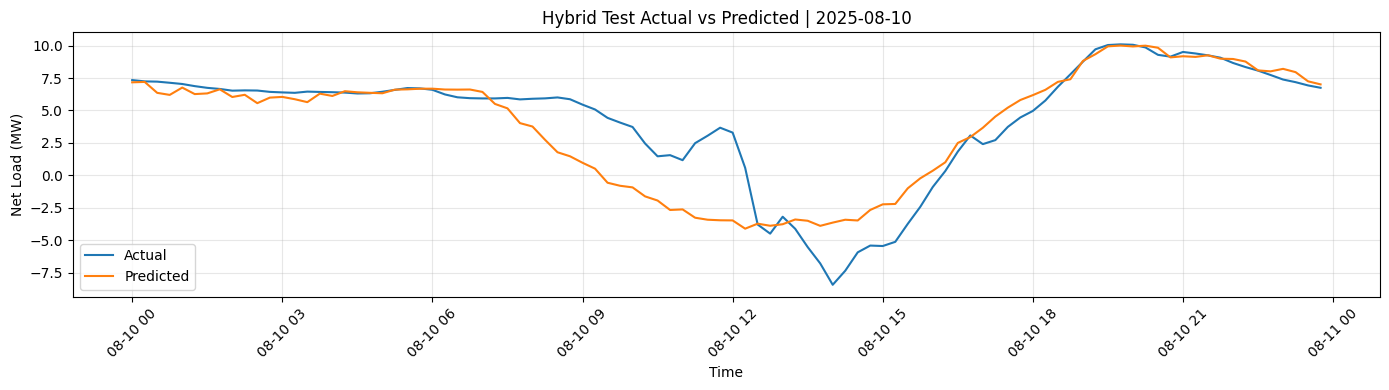

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

wanted_date = pd.Timestamp("2025-08-10").date()

idx = None
for j in range(len(true_test_mw)):  # use prediction length, not raw test_issue length
    d = (pd.Timestamp(test_issue[j]) + pd.Timedelta(minutes=15)).date()
    if d == wanted_date:
        idx = j
        break

if idx is None:
    print("Date not found in evaluated test set.")
else:
    start_ts = pd.Timestamp(test_issue[idx]) + pd.Timedelta(minutes=15)
    time_index = pd.date_range(start=start_ts, periods=96, freq="15min")

    plt.figure(figsize=(14, 4))
    plt.plot(time_index, true_test_mw[idx], label="Actual")
    plt.plot(time_index, pred_test_mw[idx], label="Predicted")
    plt.title(f"Hybrid Test Actual vs Predicted | {wanted_date}")
    plt.xlabel("Time")
    plt.ylabel("Net Load (MW)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [39]:
lgbm_test_metrics = pd.read_csv("lgbm_test_metrics.csv")

hybrid_test_metrics = pd.DataFrame([
    ["Hybrid ICEEMDAN + Transformer", "Test", 1.0327, 1.5322, "92.16%"]
], columns=["Model", "Split", "MAE_MW", "RMSE_MW", "R2_Percentage"])

compare_test_df = pd.concat([lgbm_test_metrics, hybrid_test_metrics], ignore_index=True)
compare_test_df = compare_test_df[["Model", "MAE_MW", "RMSE_MW", "R2_Percentage"]]
compare_test_df = compare_test_df.sort_values("MAE_MW").reset_index(drop=True)

compare_test_df

,Model,MAE_MW,RMSE_MW,R2_Percentage
0,Hybrid ICEEMDAN + Transformer,1.0327,1.5322,92.16%
1,LightGBM Baseline,1.1257,1.7498,89.75%
